In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/customer_support_tickets.csv")
print(df.shape)
df.head()

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [3]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [4]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


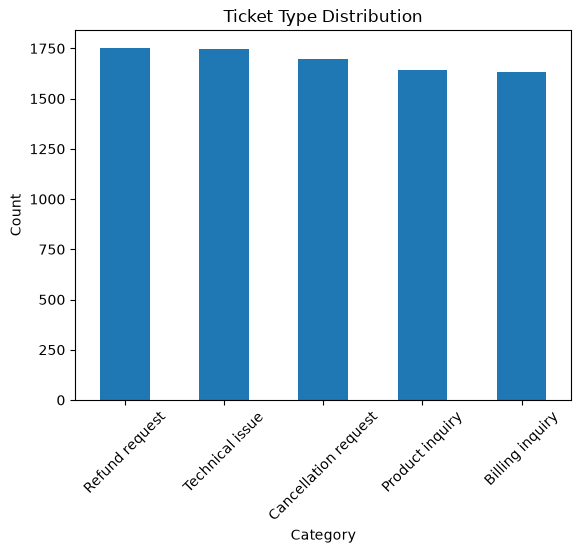

In [6]:
import matplotlib.pyplot as plt

df['Ticket Type'].value_counts().plot(kind='bar')
plt.title('Ticket Type Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [7]:
placeholder_count = df['Ticket Description'].str.contains(r'\{product_purchased\}', regex=True).sum()
print(f"Tickets with {{product_purchased}} placeholder: {placeholder_count}")
print(f"Total tickets: {len(df)}")
print(f"Percentage: {placeholder_count / len(df) * 100:.2f}%")

Tickets with {product_purchased} placeholder: 8469
Total tickets: 8469
Percentage: 100.00%


In [8]:
sample_with_placeholder = df[df['Ticket Description'].str.contains(r'\{product_purchased\}', regex=True)]
for i in range(3):
    print(sample_with_placeholder['Ticket Description'].iloc[i])
    print("---")

I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
---
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
---
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.
---


In [9]:
df['description_length'] = df['Ticket Description'].apply(lambda x: len(str(x).split()))
df['description_length'].describe()

count    8469.000000
mean       46.467352
std         8.461730
min        21.000000
25%        43.000000
50%        49.000000
75%        52.000000
max        63.000000
Name: description_length, dtype: float64

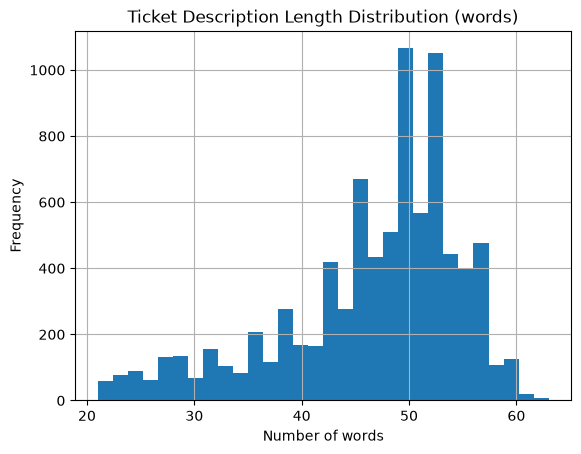

In [10]:
df['description_length'].hist(bins=30)
plt.title('Ticket Description Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

In [11]:
duplicate_count = df['Ticket Description'].duplicated().sum()
print(f"Duplicate descriptions: {duplicate_count}")
print(f"Unique descriptions: {df['Ticket Description'].nunique()}")
print(f"Total tickets: {len(df)}")

Duplicate descriptions: 392
Unique descriptions: 8077
Total tickets: 8469


In [12]:
# Find descriptions that appear in more than one category
dup_descriptions = df[df.duplicated(subset=['Ticket Description'], keep=False)]
dup_check = dup_descriptions.groupby('Ticket Description')['Ticket Type'].nunique()
print(f"Descriptions appearing in multiple categories: {(dup_check > 1).sum()}")

Descriptions appearing in multiple categories: 42


In [13]:
df['Ticket Subject'].value_counts().head(20)

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

In [14]:
pd.crosstab(df['Ticket Subject'], df['Ticket Type']).head(10)

Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Ticket Subject,,,,,
Account access,103,92,107,108,99
Battery life,106,104,101,119,112
Cancellation request,82,103,85,109,108
Data loss,89,115,91,97,99
Delivery problem,115,114,109,107,116
Display issue,91,103,80,99,105
Hardware issue,100,109,106,129,103
Installation support,108,99,99,119,105
Network problem,95,102,113,107,122


In [15]:
print(df['Ticket Priority'].value_counts())
print()
print(df['Ticket Channel'].value_counts())
print()
print(df['Ticket Status'].value_counts())

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


In [16]:
resolved = df[df['Resolution'].notna()]
print(f"Tickets with resolution: {len(resolved)}")
print(f"Percentage: {len(resolved) / len(df) * 100:.2f}%")
print()
for i in range(3):
    print("DESCRIPTION:", resolved['Ticket Description'].iloc[i])
    print("RESOLUTION:", resolved['Resolution'].iloc[i])
    print("---")

Tickets with resolution: 2769
Percentage: 32.70%

DESCRIPTION: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.
RESOLUTION: Case maybe show recently my computer follow.
---
DESCRIPTION: I'm having an issue with the {product_purchased}. Please assist.

If you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.
RESOLUTION: Try capital clearly never color toward story.
---
DESCRIPTION: I'm having an issue with the {product_purchased}. Please assist.


Note: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sud